In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 👇 Ajusta si tu carpeta no se llama así
DATA_DIR = Path("raw")

payems_path = DATA_DIR / "PAYEMS.csv"
unrate_path = DATA_DIR / "UNRATE.csv"


In [11]:
def load_fred_csv(path: Path, value_col_name: str):
    """
    FRED CSV típico: observation_date, <SERIES>
    """
    df = pd.read_csv(path)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.rename(columns={df.columns[1]: value_col_name})
    df[value_col_name] = pd.to_numeric(df[value_col_name], errors="coerce")
    df = df.dropna(subset=[value_col_name]).sort_values("observation_date")
    return df

payems = load_fred_csv(payems_path, "PAYEMS")   # nivel: miles de empleo
unrate = load_fred_csv(unrate_path, "UNRATE")   # tasa %

# Restricción de ventana (como tu figura ~2019-2025)
start = "2019-01-01"
end   = "2025-12-31"

payems = payems.query("observation_date >= @start and observation_date <= @end").copy()
unrate = unrate.query("observation_date >= @start and observation_date <= @end").copy()

# (a) cambio mensual en miles
payems["PAYEMS_change"] = payems["PAYEMS"].diff()  # miles (porque PAYEMS ya está en miles)
payems_change = payems.dropna(subset=["PAYEMS_change"]).copy()

# promedio para la línea punteada
mean_change = payems_change["PAYEMS_change"].mean()

payems_change.head(), unrate.head(), mean_change


(    observation_date  PAYEMS  PAYEMS_change
 961       2019-02-01  150065            6.0
 962       2019-03-01  150295          230.0
 963       2019-04-01  150593          298.0
 964       2019-05-01  150621           28.0
 965       2019-06-01  150839          218.0,
     observation_date  UNRATE
 852       2019-01-01     4.0
 853       2019-02-01     3.8
 854       2019-03-01     3.8
 855       2019-04-01     3.7
 856       2019-05-01     3.6,
 np.float64(114.06024096385542))

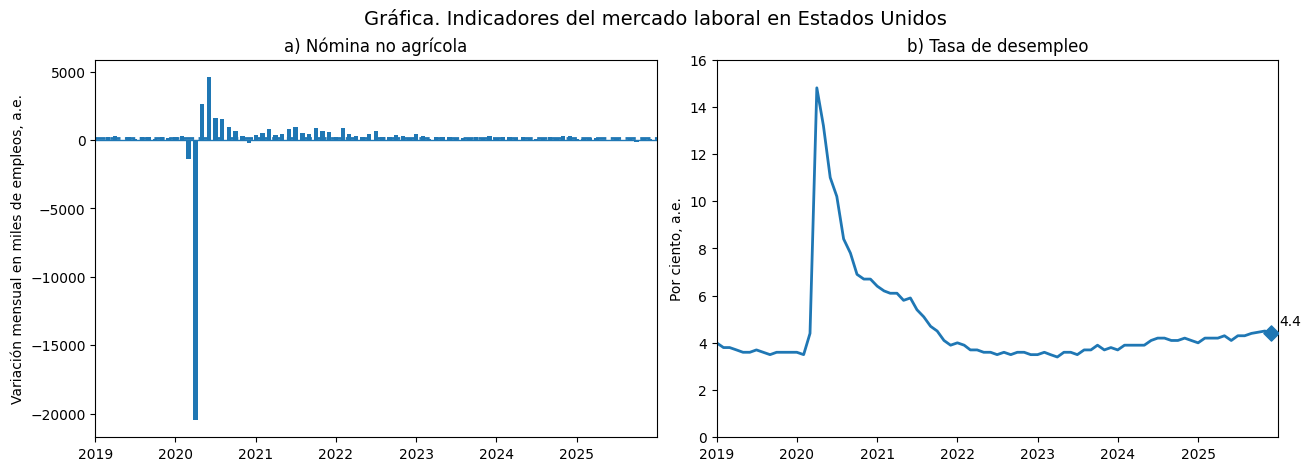

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)

# ---------------------------
# (a) Nómina no agrícola: variación mensual (miles)
# ---------------------------
ax = axes[0]
ax.bar(payems_change["observation_date"], payems_change["PAYEMS_change"], width=20)  # width ~ días

# Línea punteada de promedio
ax.axhline(mean_change, linestyle="--", linewidth=2)

ax.set_title("a) Nómina no agrícola")
ax.set_ylabel("Variación mensual en miles de empleos, a.e.")
ax.set_xlabel("")
ax.axhline(0, linewidth=1)

# Límites del eje x para que se vea como tu gráfica
ax.set_xlim(pd.to_datetime(start), pd.to_datetime(end))

# ---------------------------
# (b) Tasa de desempleo
# ---------------------------
ax2 = axes[1]
ax2.plot(unrate["observation_date"], unrate["UNRATE"], linewidth=2)

ax2.set_title("b) Tasa de desempleo")
ax2.set_ylabel("Por ciento, a.e.")
ax2.set_xlabel("")
ax2.set_xlim(pd.to_datetime(start), pd.to_datetime(end))
ax2.set_ylim(0, max(16, unrate["UNRATE"].max() + 1))

# Diamante rojo en el último punto (como tu figura)
last_date = unrate["observation_date"].iloc[-1]
last_val  = unrate["UNRATE"].iloc[-1]
ax2.scatter([last_date], [last_val], marker="D", s=60, zorder=3)
ax2.annotate(f"{last_val:.1f}", (last_date, last_val), xytext=(6, 6), textcoords="offset points")

# Título general
fig.suptitle("Gráfica. Indicadores del mercado laboral en Estados Unidos", fontsize=14)

plt.show()


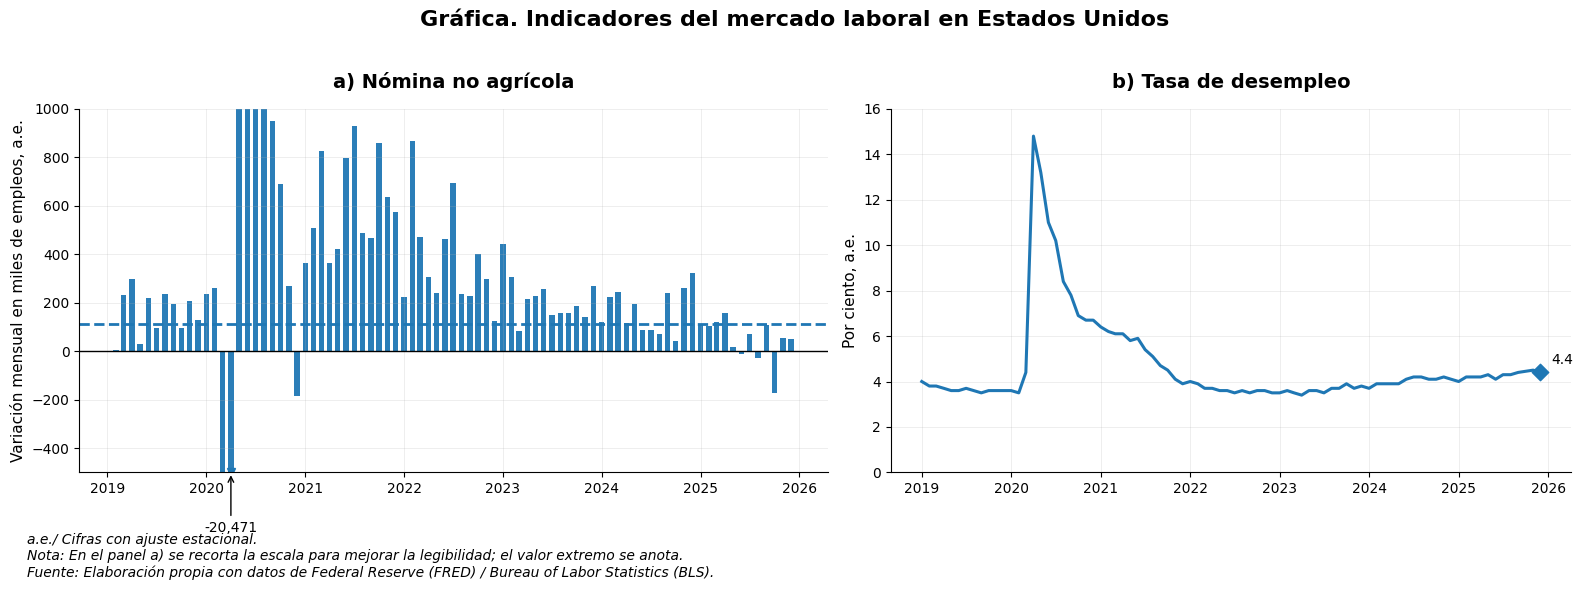

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Parámetros de estilo
# --------------------------
title_fs = 16
panel_title_fs = 14
label_fs = 11
tick_fs = 10
note_fs = 10

# --------------------------
# Crear figura
# --------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# ---- estilo ejes (como tu Gráfica 1/2)
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ==========================
# Panel (a): Nómina no agrícola (variación mensual)
# ==========================
x = payems_change["observation_date"]
y = payems_change["PAYEMS_change"]  # en miles

# Barras (más “finas” y elegantes)
ax1.bar(x, y, width=20, alpha=0.95)

# Línea de promedio (punteada roja)
mean_change = y.mean()
ax1.axhline(mean_change, linestyle="--", linewidth=2)
ax1.axhline(0, color="black", linewidth=1)

# 🔥 Manejo del outlier COVID (recorte + anotación)
# Rango “bonito” (ajústalo a gusto)
ymin, ymax = -500, 1000
ax1.set_ylim(ymin, ymax)

# Encontrar el punto más extremo (para anotarlo)
idx_min = y.idxmin()
x_min = payems_change.loc[idx_min, "observation_date"]
y_min = payems_change.loc[idx_min, "PAYEMS_change"]

# Si el mínimo queda fuera del rango visible, anótalo con flecha
if y_min < ymin:
    ax1.annotate(
        f"{y_min:,.0f}",
        xy=(x_min, ymin), xycoords="data",
        xytext=(0, -35), textcoords="offset points",
        ha="center", va="top", fontsize=10,
        arrowprops=dict(arrowstyle="->", lw=1)
    )
    # marca visual en el borde inferior (sin meter colores específicos)
    ax1.plot([x_min], [ymin], marker="v", markersize=6)

# Etiquetas / títulos
ax1.set_title("a) Nómina no agrícola", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax1.set_ylabel("Variación mensual en miles de empleos, a.e.", fontsize=label_fs)
ax1.set_xlabel("")
ax1.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Panel (b): Tasa de desempleo
# ==========================
ax2.plot(unrate["observation_date"], unrate["UNRATE"], linewidth=2.2)

# Diamante del último dato + etiqueta (como tu ejemplo)
last_date = unrate["observation_date"].iloc[-1]
last_val = unrate["UNRATE"].iloc[-1]
ax2.scatter([last_date], [last_val], marker="D", s=70, zorder=3)
ax2.annotate(
    f"{last_val:.1f}",
    (last_date, last_val),
    xytext=(8, 4), textcoords="offset points",
    fontsize=10, ha="left", va="bottom"
)

ax2.set_title("b) Tasa de desempleo", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax2.set_ylabel("Por ciento, a.e.", fontsize=label_fs)
ax2.set_xlabel("")
ax2.set_ylim(0, 16)
ax2.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Título general + nota (formato Banxico)
# ==========================
fig.suptitle(
    "Gráfica. Indicadores del mercado laboral en Estados Unidos",
    fontsize=title_fs, fontweight="bold", y=0.98
)

fig.text(
    0.02, 0.03,
    "a.e./ Cifras con ajuste estacional.\n"
    "Nota: En el panel a) se recorta la escala para mejorar la legibilidad; el valor extremo se anota.\n"
    "Fuente: Elaboración propia con datos de Federal Reserve (FRED) / Bureau of Labor Statistics (BLS).",
    va="bottom",
    fontsize=note_fs, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


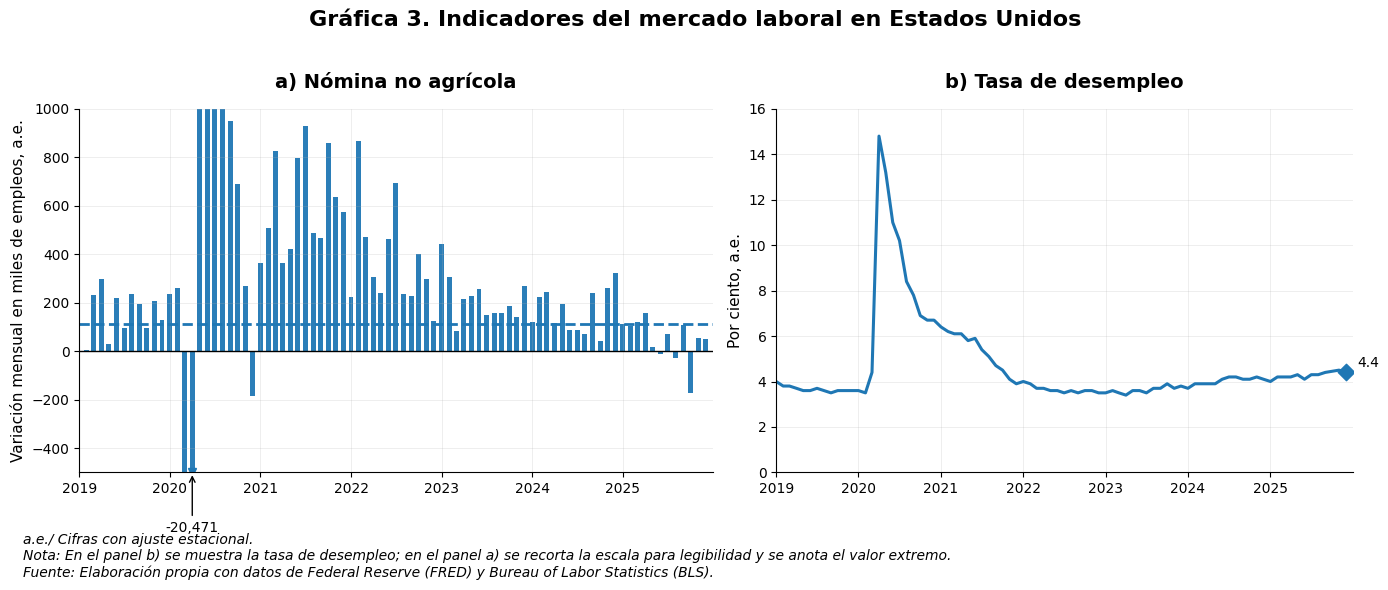

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================
# SUPONE QUE YA EXISTEN:
# payems_change  -> columnas: observation_date, PAYEMS_change
# unrate         -> columnas: observation_date, UNRATE
# start, end     -> strings tipo "2019-01-01", "2025-12-31"
# ==========================

# --------------------------
# Parámetros visuales
# --------------------------
title_fs = 16
panel_title_fs = 14
label_fs = 11
tick_fs = 10
note_fs = 10

# --------------------------
# Crear figura
# --------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# ---- estilo ejes
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ==========================
# Panel (a): Nómina no agrícola
# ==========================
x = payems_change["observation_date"]
y = payems_change["PAYEMS_change"]

ax1.bar(x, y, width=20, alpha=0.95)

# Promedio punteado
mean_change = y.mean()
ax1.axhline(mean_change, linestyle="--", linewidth=2)
ax1.axhline(0, color="black", linewidth=1)

# Recorte visual del eje Y
ymin, ymax = -500, 1000
ax1.set_ylim(ymin, ymax)

# Anotar outlier COVID
idx_min = y.idxmin()
x_min = payems_change.loc[idx_min, "observation_date"]
y_min = y.loc[idx_min]

if y_min < ymin:
    ax1.annotate(
        f"{y_min:,.0f}",
        xy=(x_min, ymin),
        xytext=(0, -35),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=10,
        arrowprops=dict(arrowstyle="->", lw=1)
    )
    ax1.plot([x_min], [ymin], marker="v", markersize=6)

ax1.set_title("a) Nómina no agrícola", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax1.set_ylabel("Variación mensual en miles de empleos, a.e.", fontsize=label_fs)
ax1.set_xlabel("")
ax1.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Panel (b): Tasa de desempleo
# ==========================
ax2.plot(unrate["observation_date"], unrate["UNRATE"], linewidth=2.2)

# Diamante último dato
last_date = unrate["observation_date"].iloc[-1]
last_val = unrate["UNRATE"].iloc[-1]

ax2.scatter([last_date], [last_val], marker="D", s=70, zorder=3)
ax2.annotate(
    f"{last_val:.1f}",
    (last_date, last_val),
    xytext=(8, 4),
    textcoords="offset points",
    fontsize=10
)

ax2.set_title("b) Tasa de desempleo", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax2.set_ylabel("Por ciento, a.e.", fontsize=label_fs)
ax2.set_xlabel("")
ax2.set_ylim(0, 16)
ax2.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Compactar eje X
# ==========================
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.margins(x=0)

ax1.set_xlim(pd.to_datetime(start), pd.to_datetime(end))
ax2.set_xlim(pd.to_datetime(start), pd.to_datetime(end))

# ==========================
# Título general + nota
# ==========================
fig.suptitle(
    "Gráfica 3. Indicadores del mercado laboral en Estados Unidos",
    fontsize=title_fs,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.02,
    0.03,
    "a.e./ Cifras con ajuste estacional.\n"
    "Nota: En el panel b) se muestra la tasa de desempleo; "
    "en el panel a) se recorta la escala para legibilidad y se anota el valor extremo.\n"
    "Fuente: Elaboración propia con datos de Federal Reserve (FRED) y Bureau of Labor Statistics (BLS).",
    fontsize=note_fs,
    style="italic",
    va="bottom"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


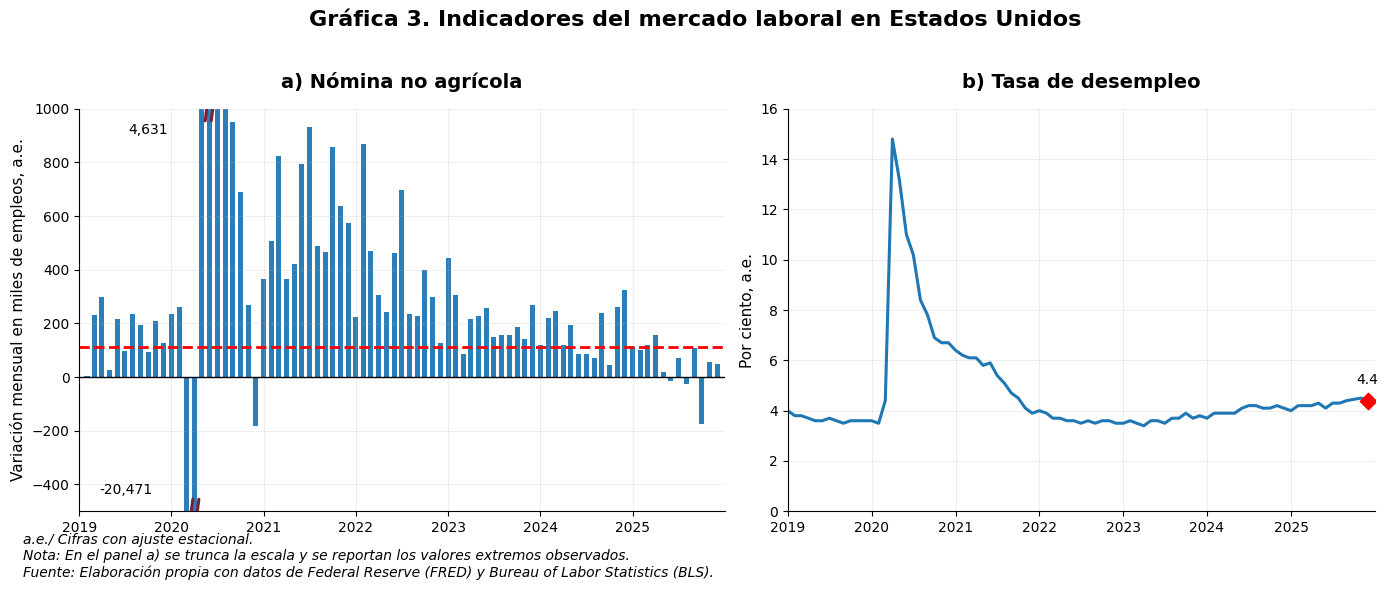

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================
# SUPONE QUE YA EXISTEN:
# payems_change  -> columnas: observation_date, PAYEMS_change   (miles)
# unrate         -> columnas: observation_date, UNRATE          (%)
# start, end     -> strings tipo "2019-01-01", "2025-12-31"
# ==========================

# --------------------------
# Parámetros visuales
# --------------------------
title_fs = 16
panel_title_fs = 14
label_fs = 11
tick_fs = 10
note_fs = 10

# Truncado panel (a)
ymin, ymax = -500, 1000  # miles (ajusta si quieres)
vino = "#7B1E3A"         # color vino pedido

def draw_trunc_marks(ax, x_dt, y_edge, where="top", color=vino, lw=2):
    """
    Dibuja dos líneas diagonales tipo '//' en el borde del truncado.
    x_dt: datetime (posición en el eje x)
    y_edge: valor y en datos (ymax o ymin)
    where: "top" o "bottom"
    """
    # tamaño del corte en unidades de x (días) y y (datos)
    dx_days = 18
    dy = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03

    x0 = x_dt - pd.Timedelta(days=dx_days)
    x1 = x_dt - pd.Timedelta(days=dx_days/3)
    x2 = x_dt + pd.Timedelta(days=dx_days/3)
    x3 = x_dt + pd.Timedelta(days=dx_days)

    if where == "top":
        y0, y1 = y_edge - dy, y_edge + dy
    else:
        y0, y1 = y_edge - dy, y_edge + dy

    # Dos diagonales paralelas (//)
    ax.plot([x0, x1], [y0, y1], color=color, lw=lw, solid_capstyle="round", zorder=5)
    ax.plot([x2, x3], [y0, y1], color=color, lw=lw, solid_capstyle="round", zorder=5)

# --------------------------
# Crear figura
# --------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# ---- estilo ejes (como tu ejemplo)
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ==========================
# Panel (a): Nómina no agrícola (variación mensual)
# ==========================
x = payems_change["observation_date"]
y = payems_change["PAYEMS_change"]  # miles

ax1.bar(x, y, width=20, alpha=0.95)

# Promedio punteado (rojo)
mean_change = y.mean()
ax1.axhline(mean_change, linestyle="--", linewidth=2, color="red")
ax1.axhline(0, color="black", linewidth=1)

# Aplicar truncado
ax1.set_ylim(ymin, ymax)

# Encontrar extremos reales
idx_min = y.idxmin()
x_min = payems_change.loc[idx_min, "observation_date"]
y_min = float(y.loc[idx_min])

idx_max = y.idxmax()
x_max = payems_change.loc[idx_max, "observation_date"]
y_max = float(y.loc[idx_max])

# ---- Caso truncado abajo: marca + valor real
if y_min < ymin:
    draw_trunc_marks(ax1, x_min, ymin, where="bottom", color=vino, lw=2.2)
    # etiqueta del valor verdadero cerca del corte (como tu figura)
    ax1.annotate(
        f"{y_min:,.0f}",
        xy=(x_min, ymin),
        xytext=(-30, 10),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
        color="black"
    )

# ---- Caso truncado arriba: marca + valor real
if y_max > ymax:
    draw_trunc_marks(ax1, x_max, ymax, where="top", color=vino, lw=2.2)
    ax1.annotate(
        f"{y_max:,.0f}",
        xy=(x_max, ymax),
        xytext=(-30, -10),
        textcoords="offset points",
        ha="right",
        va="top",
        fontsize=10,
        color="black"
    )

ax1.set_title("a) Nómina no agrícola", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax1.set_ylabel("Variación mensual en miles de empleos, a.e.", fontsize=label_fs)
ax1.set_xlabel("")
ax1.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Panel (b): Tasa de desempleo
# ==========================
ax2.plot(unrate["observation_date"], unrate["UNRATE"], linewidth=2.2)

# Diamante del último dato + etiqueta ARRIBA (centrada)
last_date = unrate["observation_date"].iloc[-1]
last_val = float(unrate["UNRATE"].iloc[-1])

ax2.scatter([last_date], [last_val], marker="D", s=70, color="red", zorder=3)
ax2.annotate(
    f"{last_val:.1f}",
    (last_date, last_val),
    xytext=(0, 10),               # 👈 arriba
    textcoords="offset points",
    ha="center", va="bottom",     # 👈 centrado sobre el diamante
    fontsize=10,
    color="black"
)

ax2.set_title("b) Tasa de desempleo", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax2.set_ylabel("Por ciento, a.e.", fontsize=label_fs)
ax2.set_xlabel("")
ax2.set_ylim(0, 16)
ax2.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Compactar eje X (como PDF)
# ==========================
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.margins(x=0)

ax1.set_xlim(pd.to_datetime(start), pd.to_datetime(end))
ax2.set_xlim(pd.to_datetime(start), pd.to_datetime(end))

# ==========================
# Título general + nota
# ==========================
fig.suptitle(
    "Gráfica 3. Indicadores del mercado laboral en Estados Unidos",
    fontsize=title_fs, fontweight="bold", y=0.98
)

fig.text(
    0.02, 0.03,
    "a.e./ Cifras con ajuste estacional.\n"
    "Nota: En el panel a) se trunca la escala y se reportan los valores extremos observados.\n"
    "Fuente: Elaboración propia con datos de Federal Reserve (FRED) y Bureau of Labor Statistics (BLS).",
    va="bottom",
    fontsize=note_fs, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


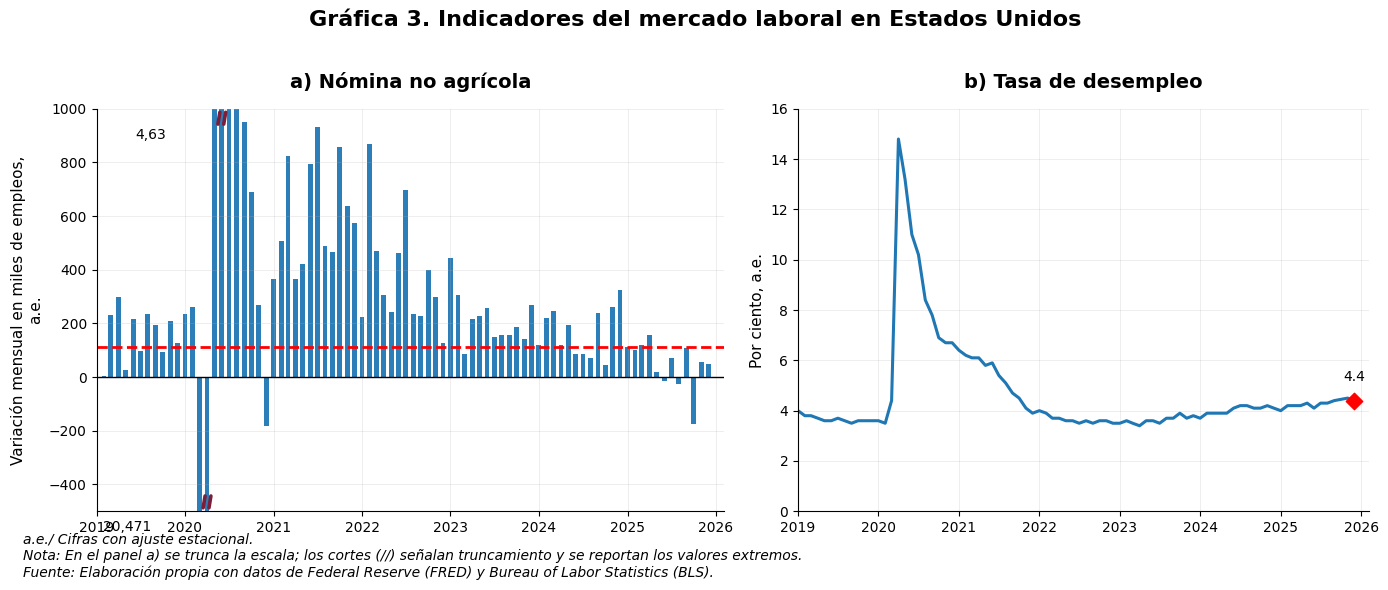

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================
# SUPONE QUE YA EXISTEN:
# payems_change  -> columnas: observation_date, PAYEMS_change   (miles)
# unrate         -> columnas: observation_date, UNRATE          (%)
# start, end     -> strings tipo "2019-01-01", "2025-12-31"
# ==========================

# --------------------------
# Parámetros visuales
# --------------------------
title_fs = 16
panel_title_fs = 14
label_fs = 11
tick_fs = 10
note_fs = 10

# Truncado panel (a) (como el PDF: visible [-500, 1000])
ymin_vis, ymax_vis = -500, 1000
vino = "#7B1E3A"

def draw_slashes(ax, x_dt, y_center, dx_days=32, dy=55, color=vino, lw=3.0):
    """
    Dibuja '//' largos estilo Banxico sobre la barra truncada.
    """
    x0 = x_dt - pd.Timedelta(days=dx_days)
    x1 = x_dt - pd.Timedelta(days=dx_days/2)
    x2 = x_dt + pd.Timedelta(days=dx_days/2)
    x3 = x_dt + pd.Timedelta(days=dx_days)

    ax.plot([x0, x1], [y_center - dy, y_center + dy],
            color=color, lw=lw, solid_capstyle="round",
            zorder=20, clip_on=False)

    ax.plot([x2, x3], [y_center - dy, y_center + dy],
            color=color, lw=lw, solid_capstyle="round",
            zorder=20, clip_on=False)

# --------------------------
# Crear figura
# --------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# ---- estilo ejes (como tu formato)
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ==========================
# Panel (a): Nómina no agrícola (variación mensual)
# ==========================
x = payems_change["observation_date"]
y = payems_change["PAYEMS_change"].astype(float)  # miles

# Barras
ax1.bar(x, y, width=20, alpha=0.95)

# Promedio punteado rojo + cero
mean_change = y.mean()
ax1.axhline(mean_change, linestyle="--", linewidth=2, color="red")
ax1.axhline(0, color="black", linewidth=1)

# Truncado visible
ax1.set_ylim(ymin_vis, ymax_vis)

# Extremos reales
idx_min = y.idxmin()
x_min = payems_change.loc[idx_min, "observation_date"]
y_min = float(y.loc[idx_min])

idx_max = y.idxmax()
x_max = payems_change.loc[idx_max, "observation_date"]
y_max = float(y.loc[idx_max])

def draw_slashes_over_bar(ax, x_dt, y_center,
                          dx_days=16, dy=22,
                          color="#7B1E3A", lw=2.6):
    """
    Dibuja los símbolos // directamente sobre una barra truncada.

    Parámetros
    ----------
    ax : matplotlib axis
        Eje donde se dibuja.
    x_dt : datetime-like
        Fecha de la barra extrema.
    y_center : float
        Nivel vertical donde se colocan los cortes (cerca del límite visible).
    dx_days : int
        Separación horizontal en días para los trazos.
    dy : float
        Altura vertical de cada trazo.
    color : str
        Color de las líneas.
    lw : float
        Grosor de línea.
    """

    # convertir por seguridad
    x_dt = pd.to_datetime(x_dt)

    # posiciones horizontales
    x0 = x_dt - pd.Timedelta(days=dx_days)
    x1 = x_dt - pd.Timedelta(days=dx_days / 2)
    x2 = x_dt + pd.Timedelta(days=dx_days / 2)
    x3 = x_dt + pd.Timedelta(days=dx_days)

    # primera diagonal
    ax.plot(
        [x0, x1],
        [y_center - dy, y_center + dy],
        color=color,
        lw=lw,
        solid_capstyle="round",
        zorder=25,
        clip_on=False,
    )

    # segunda diagonal
    ax.plot(
        [x2, x3],
        [y_center - dy, y_center + dy],
        color=color,
        lw=lw,
        solid_capstyle="round",
        zorder=25,
        clip_on=False,
    )

# --- Si hay truncado abajo: poner cortes sobre la barra extrema + valor real (miles, con coma)
if y_min < ymin_vis:
    # cortes alrededor del borde inferior visible (como en PDF, sobre la barra)
    draw_slashes_over_bar(ax1, x_min, ymin_vis + 35, dx_days=16, dy=22, color=vino, lw=2.6)

    # etiqueta del valor verdadero (miles)
    ax1.annotate(
        f"{abs(y_min):,.0f}",
        xy=(x_min, ymin_vis + 20),
        xytext=(-40, -10),
        textcoords="offset points",
        ha="right", va="top",
        fontsize=10, color="black"
    )

# --- Si hay truncado arriba: cortes + valor real (millones con coma decimal)
if y_max > ymax_vis:
    draw_slashes_over_bar(ax1, x_max, ymax_vis - 35, dx_days=16, dy=22, color=vino, lw=2.6)

    # miles -> millones (porque los datos están en miles)
    y_max_mill = y_max / 1000.0
    label_top = f"{y_max_mill:.2f}".replace(".", ",")  # estilo español "4,63"

    ax1.annotate(
        label_top,
        xy=(x_max, ymax_vis - 20),
        xytext=(-40, -10),
        textcoords="offset points",
        ha="right", va="top",
        fontsize=10, color="black"
    )

ax1.set_title("a) Nómina no agrícola", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax1.set_ylabel("Variación mensual en miles de empleos,\na.e.", fontsize=label_fs)
ax1.set_xlabel("")
ax1.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Panel (b): Tasa de desempleo
# ==========================
ax2.plot(unrate["observation_date"], unrate["UNRATE"].astype(float), linewidth=2.2)

# Diamante del último dato + etiqueta ARRIBA (centrada)
last_date = unrate["observation_date"].iloc[-1]
last_val = float(unrate["UNRATE"].iloc[-1])

ax2.scatter([last_date], [last_val], marker="D", s=70, color="red", zorder=3)
ax2.annotate(
    f"{last_val:.1f}",
    (last_date, last_val),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center", va="bottom",
    fontsize=10, color="black"
)

ax2.set_title("b) Tasa de desempleo", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax2.set_ylabel("Por ciento, a.e.", fontsize=label_fs)
ax2.set_xlabel("")
ax2.set_ylim(0, 16)
ax2.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Compactar eje X (ticks por año + sin margen)
# ==========================
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.margins(x=0)

# Un poquito de padding a la derecha para que el diamante/label no pegue con el borde
x0 = pd.to_datetime(start)
x1 = pd.to_datetime(end) + pd.Timedelta(days=35)

ax1.set_xlim(x0, x1)
ax2.set_xlim(x0, x1)

# ==========================
# Título general + nota
# ==========================
fig.suptitle(
    "Gráfica 3. Indicadores del mercado laboral en Estados Unidos",
    fontsize=title_fs, fontweight="bold", y=0.98
)

fig.text(
    0.02, 0.03,
    "a.e./ Cifras con ajuste estacional.\n"
    "Nota: En el panel a) se trunca la escala; los cortes (//) señalan truncamiento y se reportan los valores extremos.\n"
    "Fuente: Elaboración propia con datos de Federal Reserve (FRED) y Bureau of Labor Statistics (BLS).",
    va="bottom",
    fontsize=note_fs, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


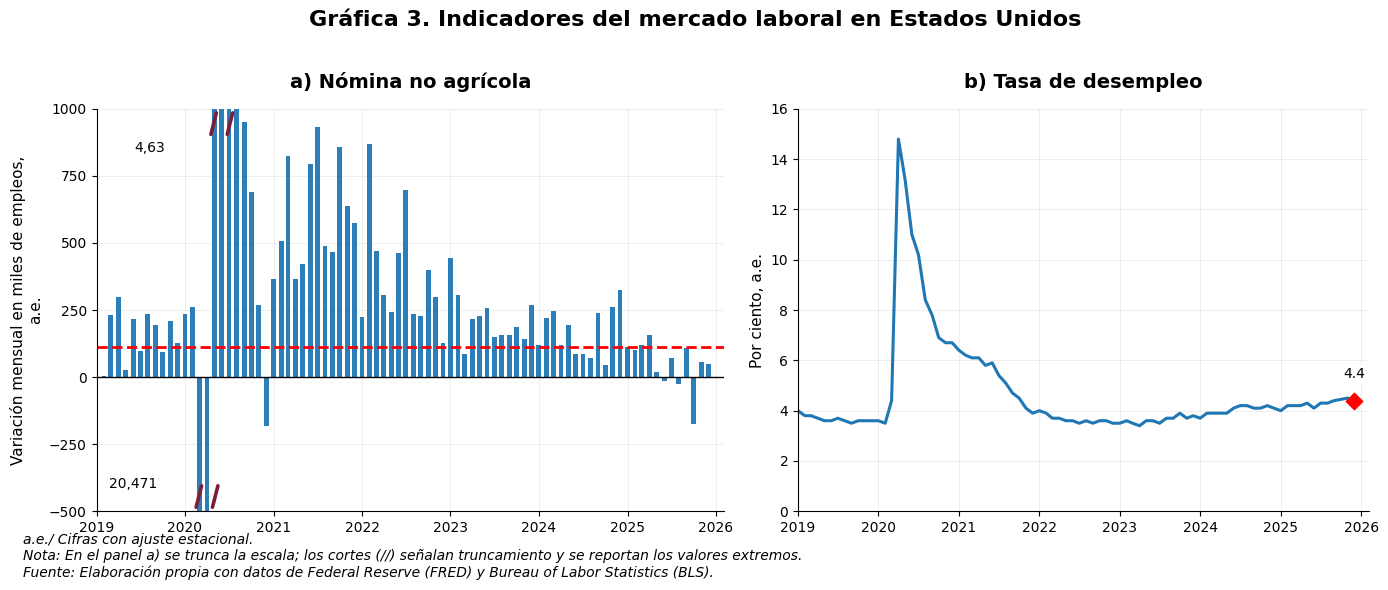

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================
# SUPONE QUE YA EXISTEN:
# payems_change  -> columnas: observation_date, PAYEMS_change   (miles)
# unrate         -> columnas: observation_date, UNRATE          (%)
# start, end     -> strings tipo "2019-01-01", "2025-12-31"
# ==========================

title_fs = 16
panel_title_fs = 14
label_fs = 11
tick_fs = 10
note_fs = 10

# Truncado panel (a)
ymin_vis, ymax_vis = -500, 1000
vino = "#7B1E3A"

def draw_slashes(ax, x_dt, y_center, dx_days=45, dy=55, color=vino, lw=3.0):
    """
    Dibuja '//' largos estilo Banxico sobre la barra truncada.
    """
    x0 = x_dt - pd.Timedelta(days=dx_days)
    x1 = x_dt - pd.Timedelta(days=dx_days/2)
    x2 = x_dt + pd.Timedelta(days=dx_days/2)
    x3 = x_dt + pd.Timedelta(days=dx_days)

    ax.plot([x0, x1], [y_center - dy, y_center + dy],
            color=color, lw=lw, solid_capstyle="round",
            zorder=20, clip_on=False)

    ax.plot([x2, x3], [y_center - dy, y_center + dy],
            color=color, lw=lw, solid_capstyle="round",
            zorder=20, clip_on=False)


# --------------------------
# Figura
# --------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ==========================
# Panel (a)
# ==========================
x = payems_change["observation_date"]
y = payems_change["PAYEMS_change"].astype(float)

ax1.bar(x, y, width=20, alpha=0.95, zorder=2)

mean_change = y.mean()

ax1.set_ylim(ymin_vis, ymax_vis)

# Extremos reales
idx_min = y.idxmin()
x_min = payems_change.loc[idx_min, "observation_date"]
y_min = float(y.loc[idx_min])

idx_max = y.idxmax()
x_max = payems_change.loc[idx_max, "observation_date"]
y_max = float(y.loc[idx_max])

# --- Cortes y etiquetas SIN empalmes
bbox_kw = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9)

# 1) Truncado abajo
if y_min < ymin_vis:
    # baja los cortes: colócalos claramente dentro del área visible
    draw_slashes(ax1, x_min, ymin_vis + 55, dx_days=45, dy=40, color=vino, lw=2.6)

    # etiqueta del valor verdadero (miles) en una zona segura (abajo-izq)
    ax1.text(
        0.02, 0.05, f"{abs(y_min):,.0f}",
        transform=ax1.transAxes,
        ha="left", va="bottom",
        fontsize=10, bbox=bbox_kw, zorder=30
    )

# 2) Truncado arriba
if y_max > ymax_vis:
    draw_slashes(ax1, x_max, ymax_vis - 55, dx_days=45, dy=40, color=vino, lw=2.6)

    # etiqueta del valor verdadero (millones con coma decimal) arriba-izq
    y_max_mill = y_max / 1000.0
    label_top = f"{y_max_mill:.2f}".replace(".", ",")

    ax1.text(
        0.06, 0.92, label_top,
        transform=ax1.transAxes,
        ha="left", va="top",
        fontsize=10, bbox=bbox_kw, zorder=30
    )

ax1.set_title("a) Nómina no agrícola", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax1.set_ylabel("Variación mensual en miles de empleos,\na.e.", fontsize=label_fs)
ax1.set_xlabel("")
ax1.tick_params(axis="both", labelsize=tick_fs)
ax1.axhline(
    mean_change,
    linestyle="--",
    linewidth=2,
    color="red",
    zorder=3,
    label="Promedio"
)

ax1.axhline(0, color="black", linewidth=1, zorder=3)



# Ticks como Banxico (opcional pero ayuda a legibilidad)
ax1.set_yticks(np.arange(-500, 1001, 250))

# ==========================
# Panel (b)
# ==========================
ax2.plot(unrate["observation_date"], unrate["UNRATE"].astype(float), linewidth=2.2, zorder=2)

last_date = unrate["observation_date"].iloc[-1]
last_val = float(unrate["UNRATE"].iloc[-1])

ax2.scatter([last_date], [last_val], marker="D", s=70, color="red", zorder=5)

# 4.4 arriba del diamante (sin empalme)
ax2.annotate(
    f"{last_val:.1f}",
    (last_date, last_val),
    xytext=(0, 14),
    textcoords="offset points",
    ha="center", va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9),
    zorder=10
)

ax2.set_title("b) Tasa de desempleo", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax2.set_ylabel("Por ciento, a.e.", fontsize=label_fs)
ax2.set_xlabel("")
ax2.set_ylim(0, 16)
ax2.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Eje X compacto + padding derecho
# ==========================
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.margins(x=0)

x0 = pd.to_datetime(start)
x1 = pd.to_datetime(end) + pd.Timedelta(days=35)  # padding para el diamante
ax1.set_xlim(x0, x1)
ax2.set_xlim(x0, x1)

# ==========================
# Título + nota
# ==========================
fig.suptitle(
    "Gráfica 3. Indicadores del mercado laboral en Estados Unidos",
    fontsize=title_fs, fontweight="bold", y=0.98
)

fig.text(
    0.02, 0.03,
    "a.e./ Cifras con ajuste estacional.\n"
    "Nota: En el panel a) se trunca la escala; los cortes (//) señalan truncamiento y se reportan los valores extremos.\n"
    "Fuente: Elaboración propia con datos de Federal Reserve (FRED) y Bureau of Labor Statistics (BLS).",
    va="bottom", fontsize=note_fs, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


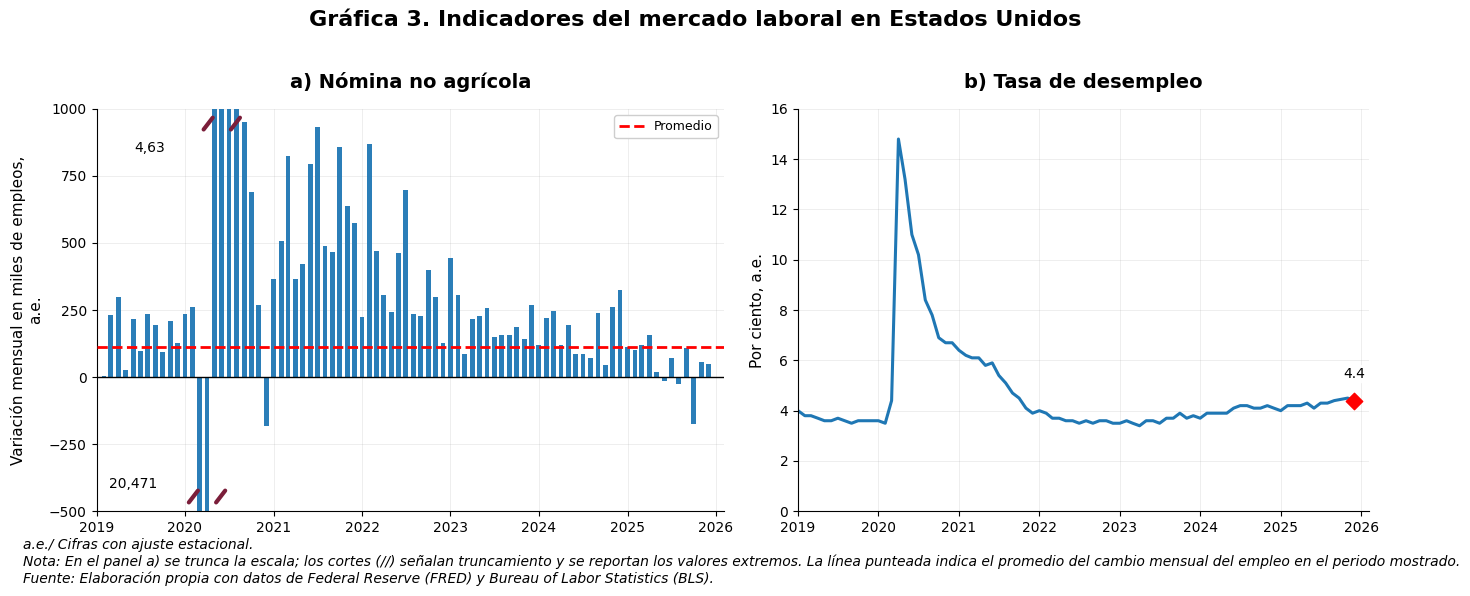

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================
# SUPONE QUE YA EXISTEN:
# payems_change  -> columnas: observation_date, PAYEMS_change   (miles)
# unrate         -> columnas: observation_date, UNRATE          (%)
# start, end     -> strings tipo "2019-01-01", "2025-12-31"
# ==========================

# --------------------------
# Parámetros visuales
# --------------------------
title_fs = 16
panel_title_fs = 14
label_fs = 11
tick_fs = 10
note_fs = 10

# Panel (a): rango visible (truncado)
ymin_vis, ymax_vis = -500, 1000
vino = "#7B1E3A"

def draw_slashes(ax, x_dt, y_center, dx_days=75, dy=22, color=vino, lw=3.0):
    """
    Dibuja '//' largos y más acostados (menos verticales).
    dx_days controla el largo horizontal.
    dy controla la inclinación (más chico = más acostado).
    """
    x0 = x_dt - pd.Timedelta(days=dx_days)
    x1 = x_dt - pd.Timedelta(days=dx_days/2)
    x2 = x_dt + pd.Timedelta(days=dx_days/2)
    x3 = x_dt + pd.Timedelta(days=dx_days)

    ax.plot([x0, x1], [y_center - dy, y_center + dy],
            color=color, lw=lw, solid_capstyle="round",
            zorder=20, clip_on=False)
    ax.plot([x2, x3], [y_center - dy, y_center + dy],
            color=color, lw=lw, solid_capstyle="round",
            zorder=20, clip_on=False)

# --------------------------
# Crear figura
# --------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# ---- estilo ejes (Banxico-like)
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ==========================
# Panel (a): Nómina no agrícola (variación mensual)
# ==========================
x = payems_change["observation_date"]
y = payems_change["PAYEMS_change"].astype(float)  # miles

# Barras
ax1.bar(x, y, width=20, alpha=0.95, zorder=2)

# Línea punteada roja = promedio del cambio mensual (en el periodo mostrado)
mean_change = y.mean()
ax1.axhline(mean_change, linestyle="--", linewidth=2, color="red", zorder=3, label="Promedio")
ax1.axhline(0, color="black", linewidth=1, zorder=3)

# Truncado visible
ax1.set_ylim(ymin_vis, ymax_vis)

# Extremos reales (para reportarlos)
idx_min = y.idxmin()
x_min = payems_change.loc[idx_min, "observation_date"]
y_min = float(y.loc[idx_min])

idx_max = y.idxmax()
x_max = payems_change.loc[idx_max, "observation_date"]
y_max = float(y.loc[idx_max])

# Etiquetas con fondo blanco para que no empalmen
bbox_kw = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9)

# Truncado abajo: cortes + valor verdadero (miles)
if y_min < ymin_vis:
    draw_slashes(ax1, x_min, ymin_vis + 55, dx_days=75, dy=22, color=vino, lw=3.0)
    ax1.text(
        0.02, 0.05, f"{abs(y_min):,.0f}",
        transform=ax1.transAxes,
        ha="left", va="bottom",
        fontsize=10, bbox=bbox_kw, zorder=30
    )

# Truncado arriba: cortes + valor verdadero (millones con coma decimal)
if y_max > ymax_vis:
    draw_slashes(ax1, x_max, ymax_vis - 55, dx_days=75, dy=22, color=vino, lw=3.0)
    y_max_mill = y_max / 1000.0  # miles -> millones
    label_top = f"{y_max_mill:.2f}".replace(".", ",")
    ax1.text(
        0.06, 0.92, label_top,
        transform=ax1.transAxes,
        ha="left", va="top",
        fontsize=10, bbox=bbox_kw, zorder=30
    )

# Formato panel (a)
ax1.set_title("a) Nómina no agrícola", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax1.set_ylabel("Variación mensual en miles de empleos,\na.e.", fontsize=label_fs)
ax1.set_xlabel("")
ax1.tick_params(axis="both", labelsize=tick_fs)
ax1.set_yticks(np.arange(-500, 1001, 250))

# Leyenda dentro del panel (a)
ax1.legend(
    loc="upper right",
    fontsize=9,
    frameon=True,
    framealpha=0.95,
    borderpad=0.4
)

# ==========================
# Panel (b): Tasa de desempleo
# ==========================
ax2.plot(unrate["observation_date"], unrate["UNRATE"].astype(float), linewidth=2.2, zorder=2)

# Diamante del último dato + etiqueta ARRIBA (centrada)
last_date = unrate["observation_date"].iloc[-1]
last_val = float(unrate["UNRATE"].iloc[-1])

ax2.scatter([last_date], [last_val], marker="D", s=70, color="red", zorder=5)
ax2.annotate(
    f"{last_val:.1f}",
    (last_date, last_val),
    xytext=(0, 14),
    textcoords="offset points",
    ha="center", va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9),
    zorder=10
)

# Formato panel (b)
ax2.set_title("b) Tasa de desempleo", fontsize=panel_title_fs, fontweight="bold", pad=15)
ax2.set_ylabel("Por ciento, a.e.", fontsize=label_fs)
ax2.set_xlabel("")
ax2.set_ylim(0, 16)
ax2.tick_params(axis="both", labelsize=tick_fs)

# ==========================
# Eje X compacto + padding derecho (para el diamante)
# ==========================
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.margins(x=0)

x0 = pd.to_datetime(start)
x1 = pd.to_datetime(end) + pd.Timedelta(days=35)
ax1.set_xlim(x0, x1)
ax2.set_xlim(x0, x1)

# ==========================
# Título general + nota
# ==========================
fig.suptitle(
    "Gráfica 3. Indicadores del mercado laboral en Estados Unidos",
    fontsize=title_fs, fontweight="bold", y=0.98
)

fig.text(
    0.02, 0.02,
    "a.e./ Cifras con ajuste estacional.\n"
    "Nota: En el panel a) se trunca la escala; los cortes (//) señalan truncamiento y se reportan los valores extremos. "
    "La línea punteada indica el promedio del cambio mensual del empleo en el periodo mostrado.\n"
    "Fuente: Elaboración propia con datos de Federal Reserve (FRED) y Bureau of Labor Statistics (BLS).",
    va="bottom", fontsize=note_fs, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()
